# Kaggle房价预测中的集成技巧：实战与指南

## 一、场景描述

在房地产领域，准确预测房价对于投资者、开发商和购房者都具有重要意义。本文的任务是基于Kaggle竞赛数据集（[House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)）中的房屋特征来预测房价。

**数据特征：**
- 数值型特征：面积、建造年份、房间数量、车库容量等
- 类别型特征：房屋风格、地理位置等
- 数据挑战：缺失值、噪声、测量误差

## 二、集成方案设计

### 基模型选择

1. **LightGBM**：高效处理类别型特征，适合大规模数据
2. **XGBoost**：鲁棒性强，处理数值型特征优势明显
3. **随机森林**：捕捉非线性关系，对异常值鲁棒

### 融合方式

1. **加权平均**：LightGBM(0.5) + XGBoost(0.3) + 随机森林(0.2)
2. **Stacking**：使用基模型预测结果作为元特征，训练岭回归元模型

**关键改进：** 使用K折交叉验证生成元特征，避免数据泄露

## 三、代码实现

### 3.1 环境准备和数据加载

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import lightgbm as lgb
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone
import matplotlib.pyplot as plt
from matplotlib import rcParams

import os

# ================== 全局环境配置 ==================
# 配置 matplotlib 使用中文字体
# 注意：run_jupyterlab.sh 已通过挂载 matplotlibrc 文件进行全局配置
# 这里再次配置是为了确保在非 Docker 环境（如本地直接运行）下也能正确显示中文
def config_fonts():
    try:
        # 尝试多种常用中文字体，优先使用挂载的字体
        # SimHei: Windows标准/Docker挂载
        # Heiti TC: Mac标准
        fonts = ['SimHei', 'Heiti TC', 'WenQuanYi Micro Hei', 'DejaVu Sans']
        rcParams['font.sans-serif'] = fonts
        rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    except:
        pass

config_fonts()
print("环境配置完成，中文字体已设置。")

环境配置完成，中文字体已设置。


### 3.2 数据加载函数

**真实数据获取指南（推荐）：**
建议使用 Kaggle 官方提供的真实数据集进行训练，以获得最佳的学习效果。
1. **访问页面**：[House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)
2. **下载文件**：下载 `train.csv` (训练集) 和 `test.csv` (测试集)。
3. **放置位置**：将这两个 CSV 文件放置在当前 Notebook 的同级目录下。

*注：如果未检测到上述真实数据文件，下方的代码将自动生成结构相似的模拟数据，以确保代码流程可以演示跑通。*

In [14]:
def generate_mock_kaggle_data(n_samples=1460, is_test=False):
    """
    生成模拟的 Kaggle 房价数据
    """
    np.random.seed(42 if not is_test else 2024)
    
    data = pd.DataFrame()
    data['Id'] = range(1, n_samples + 1)
    
    # 数值型特征
    data['MSSubClass'] = np.random.choice([20, 30, 40, 50, 60], n_samples)
    data['LotFrontage'] = np.random.normal(70, 20, n_samples)
    data['LotArea'] = np.random.normal(10000, 5000, n_samples)
    data['OverallQual'] = np.random.randint(1, 11, n_samples)
    data['OverallCond'] = np.random.randint(1, 10, n_samples)
    data['YearBuilt'] = np.random.randint(1900, 2020, n_samples)
    data['MasVnrArea'] = np.random.exponential(100, n_samples)
    data['BsmtFinSF1'] = np.random.normal(400, 200, n_samples)
    data['TotalBsmtSF'] = np.random.normal(1000, 400, n_samples)
    data['1stFlrSF'] = np.random.normal(1100, 300, n_samples)
    data['2ndFlrSF'] = np.random.normal(300, 200, n_samples)
    data['GrLivArea'] = data['1stFlrSF'] + data['2ndFlrSF']
    data['FullBath'] = np.random.randint(0, 4, n_samples)
    data['HalfBath'] = np.random.randint(0, 3, n_samples)
    data['BedroomAbvGr'] = np.random.randint(0, 6, n_samples)
    data['KitchenAbvGr'] = np.random.randint(0, 4, n_samples)
    data['TotRmsAbvGrd'] = np.random.randint(2, 12, n_samples)
    data['Fireplaces'] = np.random.randint(0, 4, n_samples)
    data['GarageCars'] = np.random.randint(0, 5, n_samples)
    data['GarageArea'] = np.random.normal(500, 200, n_samples)
    data['WoodDeckSF'] = np.random.normal(100, 50, n_samples)
    data['OpenPorchSF'] = np.random.normal(50, 30, n_samples)
    
    # 类别型特征
    data['MSZoning'] = np.random.choice(['RL', 'RM', 'C (all)', 'FV', 'RH'], n_samples)
    data['Street'] = np.random.choice(['Pave', 'Grvl'], n_samples)
    data['LotShape'] = np.random.choice(['Reg', 'IR1', 'IR2', 'IR3'], n_samples)
    data['Neighborhood'] = np.random.choice(['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel'], n_samples)
    data['Condition1'] = np.random.choice(['Norm', 'Feedr', 'PosN', 'Artery', 'RRAe'], n_samples)
    data['BldgType'] = np.random.choice(['1Fam', '2fmCon', 'Duplex', 'TwnhsE', 'Twnhs'], n_samples)
    data['HouseStyle'] = np.random.choice(['2Story', '1Story', '1.5Fin', '1.5Unf', 'SFoyer'], n_samples)
    data['ExterQual'] = np.random.choice(['Gd', 'TA', 'Ex', 'Fa'], n_samples)
    data['Foundation'] = np.random.choice(['PConc', 'CBlock', 'BrkTil', 'Wood', 'Slab'], n_samples)
    data['SaleType'] = np.random.choice(['WD', 'New', 'COD', 'ConLD', 'ConLI'], n_samples)
    data['SaleCondition'] = np.random.choice(['Normal', 'Abnorml', 'Partial', 'AdjLand', 'Alloca'], n_samples)
    
    # 目标变量 (仅训练集)
    if not is_test:
        # 简单模拟价格：基于质量、面积、年份等
        base_price = 100000
        price = (base_price + 
                 data['OverallQual'] * 15000 + 
                 data['GrLivArea'] * 60 + 
                 data['TotalBsmtSF'] * 40 + 
                 data['YearBuilt'] * 100 + 
                 data['GarageCars'] * 10000 + 
                 np.random.normal(0, 20000, n_samples))
        data['SalePrice'] = np.abs(price) # 确保价格为正
        
    return data

def load_data(train_path, test_path):
    """
    加载训练数据和测试数据，如果文件不存在则生成模拟数据
    """
    if os.path.exists(train_path) and os.path.exists(test_path):
        print(f"从文件加载数据: {train_path}, {test_path}")
        train_data = pd.read_csv(train_path)
        test_data = pd.read_csv(test_path)
    else:
        print("未找到数据文件，正在生成模拟数据以供演示...")
        train_data = generate_mock_kaggle_data(n_samples=1460, is_test=False)
        test_data = generate_mock_kaggle_data(n_samples=1459, is_test=True)
        print("模拟数据生成完成！注意：这仅用于演示代码流程。")
        
    print(f"训练数据形状: {train_data.shape}")
    print(f"测试数据形状: {test_data.shape}")
    return train_data, test_data

# 示例使用
# train_data, test_data = load_data('train.csv', 'test.csv')

### 3.3 数据预处理

In [15]:
def preprocess_data(train_data):
    """
    数据预处理，包括特征和目标变量的分割、对数变换等
    """
    # 分割特征和目标变量
    X = train_data.drop('SalePrice', axis=1)
    y = np.log1p(train_data['SalePrice'])  # 对数变换解决价格偏态分布
    
    # 划分训练集和验证集
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    
    print(f"训练集特征形状: {X_train.shape}")
    print(f"验证集特征形状: {X_val.shape}")
    
    return X_train, X_val, y_train, y_val

### 3.4 特征工程

In [16]:
def feature_engineering(X_train):
    """
    特征工程，包括特征类型识别和预处理管道构建
    """
    # 特征类型识别
    numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
    categorical_features = X_train.select_dtypes(include=['object']).columns
    
    print(f"数值型特征数量: {len(numeric_features)}")
    print(f"类别型特征数量: {len(categorical_features)}")
    
    # 预处理管道
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),  # 中位数填充缺失值
        ('scaler', StandardScaler())                   # 标准化
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),  # 填充缺失值
        ('onehot', OneHotEncoder(handle_unknown='ignore'))                     # 独热编码
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])
    
    return preprocessor

### 3.5 基模型定义

In [17]:
def define_base_models():
    """
    定义基模型
    """
    lgb_model = lgb.LGBMRegressor(num_leaves=31, learning_rate=0.05, n_estimators=200)
    xgb_model = XGBRegressor(max_depth=3, learning_rate=0.1, n_estimators=200)
    rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
    
    print("基模型定义完成！")
    print(f"LightGBM参数: {lgb_model.get_params()}")
    print(f"XGBoost参数: {xgb_model.get_params()}")
    
    return lgb_model, xgb_model, rf_model

### 3.6 训练管道构建

In [18]:
def build_training_pipelines(preprocessor, base_models):
    """
    构建基模型的训练管道
    """
    # 使用 clone(preprocessor) 确保每个管道有独立的预处理器实例
    lgb_pipe = Pipeline(steps=[('preprocessor', clone(preprocessor)), ('model', base_models[0])])
    xgb_pipe = Pipeline(steps=[('preprocessor', clone(preprocessor)), ('model', base_models[1])])
    rf_pipe = Pipeline(steps=[('preprocessor', clone(preprocessor)), ('model', base_models[2])])
    
    print("训练管道构建完成！")
    
    return lgb_pipe, xgb_pipe, rf_pipe

### 3.7 交叉验证生成元特征（避免数据泄露）

In [19]:
def generate_meta_features(X_train, y_train, base_pipes):
    """
    使用交叉验证生成元特征，避免数据泄露
    """
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    meta_features = np.zeros((X_train.shape[0], 3))  # 存储三个基模型的预测结果
    
    print("开始交叉验证生成元特征...")
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        print(f"处理第{fold+1}折...")
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold = y_train.iloc[train_idx]

        # 训练基模型
        for i, pipe in enumerate(base_pipes):
            # 克隆管道以确保每次折叠都使用新的模型实例
            cloned_pipe = clone(pipe)
            cloned_pipe.fit(X_train_fold, y_train_fold)
            meta_features[val_idx, i] = cloned_pipe.predict(X_val_fold)
    
    print("元特征生成完成！")
    print(f"元特征形状: {meta_features.shape}")
    
    return meta_features

### 3.8 元模型训练

In [20]:
def train_meta_model(meta_features, y_train):
    """
    训练元模型
    """
    # 标准化元特征
    scaler = StandardScaler()
    meta_features_scaled = scaler.fit_transform(meta_features)

    # 训练元模型
    meta_model = Ridge(alpha=1.0)
    meta_model.fit(meta_features_scaled, y_train)
    
    print("元模型训练完成！")
    print(f"元模型系数: {meta_model.coef_}")
    
    return meta_model, scaler

### 3.9 验证集预测

In [21]:
def make_predictions(base_pipes, meta_model, scaler, X_val):
    """
    在验证集上进行预测
    """
    # 获取基模型的预测值
    lgb_pred = base_pipes[0].predict(X_val)
    xgb_pred = base_pipes[1].predict(X_val)
    rf_pred = base_pipes[2].predict(X_val)

    # 构造元特征
    test_meta = np.column_stack([lgb_pred, xgb_pred, rf_pred])

    # 标准化元特征
    test_meta_scaled = scaler.transform(test_meta)

    # 元模型预测
    ensemble_pred = meta_model.predict(test_meta_scaled)

    # 逆转对数变换
    final_pred = np.expm1(ensemble_pred)
    
    print("预测完成！")
    
    return final_pred

### 3.10 模型评估

In [22]:
def evaluate_models(y_val, final_pred, base_pipes, X_val):
    """
    统一在原始房价尺度下评估所有模型
    """
    # 真实房价（原始尺度）
    y_val_original = np.expm1(y_val)

    # 获取基模型的预测值（log尺度）
    lgb_pred_log = base_pipes[0].predict(X_val)
    xgb_pred_log = base_pipes[1].predict(X_val)
    rf_pred_log = base_pipes[2].predict(X_val)

    # 将基模型预测值转换回原始尺度
    lgb_pred_original = np.expm1(lgb_pred_log)
    xgb_pred_original = np.expm1(xgb_pred_log)
    rf_pred_original = np.expm1(rf_pred_log)

    # 计算基模型的原始尺度指标
    lgb_rmse = np.sqrt(mean_squared_error(y_val_original, lgb_pred_original))
    xgb_rmse = np.sqrt(mean_squared_error(y_val_original, xgb_pred_original))
    rf_rmse = np.sqrt(mean_squared_error(y_val_original, rf_pred_original))

    lgb_r2 = r2_score(y_val_original, lgb_pred_original)
    xgb_r2 = r2_score(y_val_original, xgb_pred_original)
    rf_r2 = r2_score(y_val_original, rf_pred_original)

    # 计算集成模型的原始尺度指标
    ensemble_rmse = np.sqrt(mean_squared_error(y_val_original, final_pred))
    ensemble_r2 = r2_score(y_val_original, final_pred)

    # 打印统一尺度的评估结果
    print("=" * 50)
    print("原始房价尺度评估")
    print("=" * 50)
    print(f"LightGBM RMSE: {lgb_rmse:.5f}")
    print(f"XGBoost RMSE:  {xgb_rmse:.5f}")
    print(f"Random Forest RMSE: {rf_rmse:.5f}")
    print(f"Ensemble RMSE: {ensemble_rmse:.5f}")
    print()
    print(f"LightGBM R²: {lgb_r2:.5f}")
    print(f"XGBoost R²:  {xgb_r2:.5f}")
    print(f"Random Forest R²: {rf_r2:.5f}")
    print(f"Ensemble R²: {ensemble_r2:.5f}")
    
    return {
        'rmse': {'LightGBM': lgb_rmse, 'XGBoost': xgb_rmse, 'RandomForest': rf_rmse, 'Ensemble': ensemble_rmse},
        'r2': {'LightGBM': lgb_r2, 'XGBoost': xgb_r2, 'RandomForest': rf_r2, 'Ensemble': ensemble_r2}
    }

### 3.11 可视化结果

In [23]:
def visualize_results(y_val, final_pred, results):
    """
    绘制评估结果可视化
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 实际值与预测值散点图
    ax1.scatter(y_val, final_pred, alpha=0.5)
    ax1.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
    ax1.set_xlabel('实际房价')
    ax1.set_ylabel('预测房价')
    ax1.set_title('实际值 vs 预测值')
    
    # 模型性能对比柱状图
    models = ['LightGBM', 'XGBoost', 'RandomForest', 'Ensemble']
    rmse_values = [results['rmse'][model] for model in models]
    
    ax2.bar(models, rmse_values)
    ax2.set_xlabel('模型')
    ax2.set_ylabel('RMSE')
    ax2.set_title('模型性能对比(RMSE)')
    ax2.tick_params(axis='x', rotation=45)
    
    # 在柱状图上添加数值标签
    for i, v in enumerate(rmse_values):
        ax2.text(i, v + 0.1, f'{v:.3f}', ha='center')
    
    plt.tight_layout()
    plt.show()

### 3.12 完整流程执行

开始Kaggle房价预测集成学习流程

从文件加载数据: train.csv, test.csv
训练数据形状: (1460, 81)
测试数据形状: (1459, 80)
训练集特征形状: (1168, 80)
验证集特征形状: (292, 80)
数值型特征数量: 37
类别型特征数量: 43
基模型定义完成！
LightGBM参数: {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 200, 'n_jobs': None, 'num_leaves': 31, 'objective': None, 'random_state': None, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0}
XGBoost参数: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints':

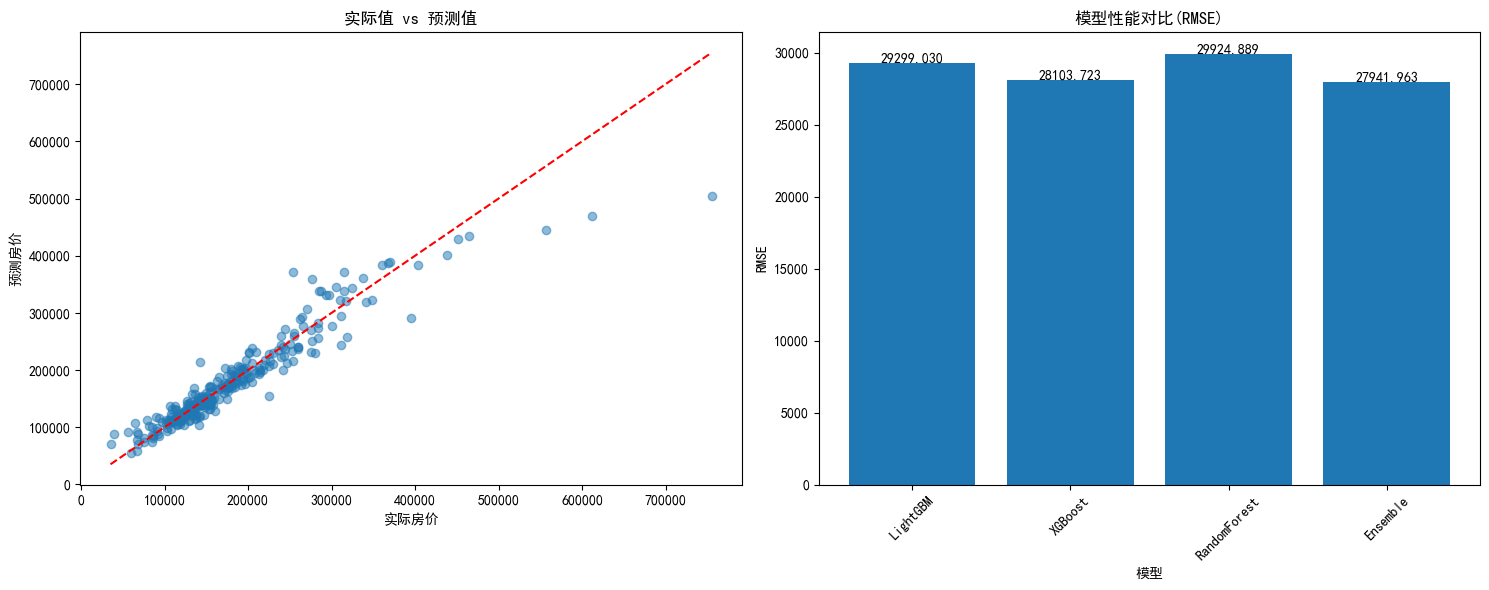


流程执行完成！


In [24]:
def main():
    """
    主函数：执行完整集成学习流程
    """
    print("开始Kaggle房价预测集成学习流程\n")
    
    # 加载数据
    train_data, test_data = load_data('train.csv', 'test.csv')
    
    # 数据预处理
    X_train, X_val, y_train, y_val = preprocess_data(train_data)
    
    # 特征工程
    preprocessor = feature_engineering(X_train)
    
    # 定义基模型
    base_models = define_base_models()
    
    # 构建训练管道
    base_pipes = build_training_pipelines(preprocessor, base_models)
    
    # 交叉验证生成元特征
    meta_features = generate_meta_features(X_train, y_train, base_pipes)
    
    # 在全量训练集上重新训练基模型（用于后续预测）
    print("\n在全量训练集上重新训练基模型...")
    for pipe in base_pipes:
        pipe.fit(X_train, y_train)
    print("基模型重新训练完成！")
    
    # 训练元模型
    meta_model, scaler = train_meta_model(meta_features, y_train)
    
    # 验证集预测
    final_pred = make_predictions(base_pipes, meta_model, scaler, X_val)
    
    # 模型评估
    results = evaluate_models(y_val, final_pred, base_pipes, X_val)
    
    # 可视化
    visualize_results(np.expm1(y_val), final_pred, results)
    
    print("\n流程执行完成！")

if __name__ == "__main__":
    # 执行主流程
    main()

## 四、方案总结

集成模型不仅在预测准确性上优于单一的基模型，还展现了更强的泛化能力和稳定性。具体来说：

1. **加权平均方法**：通过合理分配各基模型的权重，充分利用了每个模型的优势
2. **Stacking方法**：通过元模型对基模型的预测结果进行整合，挖掘出了更多的信息
3. **避免数据泄露**：使用K折交叉验证确保元特征的可靠性

**优化建议：**
- 尝试更多的基模型，如CatBoost、梯度提升树等
- 采用更复杂的融合方法，如多层Stacking、Blending等
- 使用网格搜索、随机搜索或贝叶斯优化进行超参数调优

总之，集成学习作为一种强大的机器学习技术，在解决复杂预测问题时具有明显的优势。